In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path
zip_path = "/content/drive/MyDrive/early-fire-detection/zippy/data.zip"
!unzip -o -q {zip_path} -d /

In [4]:
import sys
from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/early-fire-detection")
sys.path.insert(0, str(PROJECT_ROOT))

In [5]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [6]:
from helpers.utils import set_seed, make_run_dir, load_checkpoint, train_detection_run, save_run_config
from helpers.datahelperrr import FireDataset, collate_fn, evaluate_map

In [7]:
DATA_DIR = Path("/data")
RUNS = PROJECT_ROOT / "models" / "runs"
NUM_CLASSES = 3  # background=0, fire=1, smoke=2
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [8]:
def build_fasterrcnn(num_classes=NUM_CLASSES, trainable_backbone_layers=3, box_batch_size_per_image=512, box_positive_fraction=0.25):
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1
    model = fasterrcnn_resnet50_fpn_v2(weights=weights, trainable_backbone_layers=trainable_backbone_layers, box_batch_size_per_image=box_batch_size_per_image, box_positive_fraction=box_positive_fraction)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    model.transform.min_size = (640,)
    model.transform.max_size = 640
    return model

In [9]:
train_ds = FireDataset(DATA_DIR / "train", augment=True)
val_ds = FireDataset(DATA_DIR / "val", augment=False)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=collate_fn, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=4, pin_memory=True)

In [ ]:
lr_sweep = [0.001, 0.005, 0.01, 0.02]
results = []

for lr in lr_sweep:
    lr_tag = str(lr).replace(".", "")
    set_seed(42)
    model = build_fasterrcnn(num_classes=NUM_CLASSES, trainable_backbone_layers=3).to(device)
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=0.0005)
    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_l3_lr{lr_tag}_hyper")
    save_run_config(run_dir, {
        "lr": lr,
        "epochs": 10,
        "trainable_backbone_layers": 3,
        "optimizer": "SGD",
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "batch_size": 8,
        "augment": True,
        "seed": 42,
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })

    try: 
        train_detection_run(model, optimizer, train_loader, val_loader, device, run_dir, epochs=10)
        df = pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "lr": lr,
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "ap50_fire": float(best["ap50_fire"]),
            "ap50_smoke": float(best["ap50_smoke"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"Training failed for {lr}: {e}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 239MB/s] 


Epoch 1, Step 200, Loss: 0.136032657250762
Epoch 1, Step 400, Loss: 0.13698656703345477
AP@0.50  fire: 0.918
AP@0.50  smoke: 0.859
mAP@0.50: 0.889
AP@0.75  fire: 0.651
AP@0.75  smoke: 0.383
mAP@0.75: 0.517
Epoch 1: val_total 0.13265074613544106, map50 0.8887831870738232, map75 0.5167389454299297, 178.5014410018921s
Epoch 2, Step 200, Loss: 0.12126646714285017
Epoch 2, Step 400, Loss: 0.11944783383049071
AP@0.50  fire: 0.947
AP@0.50  smoke: 0.882
mAP@0.50: 0.914
AP@0.75  fire: 0.703
AP@0.75  smoke: 0.542
mAP@0.75: 0.623
Epoch 2: val_total 0.11944180585306846, map50 0.9140694917373997, map75 0.6229305174484168, 176.68602013587952s
Epoch 3, Step 200, Loss: 0.10831738835200667
Epoch 3, Step 400, Loss: 0.11021336353383958
AP@0.50  fire: 0.957
AP@0.50  smoke: 0.896
mAP@0.50: 0.926
AP@0.75  fire: 0.718
AP@0.75  smoke: 0.476
mAP@0.75: 0.597
Epoch 3: val_total 0.11161745787581052, map50 0.9262171260294255, map75 0.5970488682213808, 177.0595109462738s
Epoch 4, Step 200, Loss: 0.10519118815660476

In [ ]:
LR_RUNS = [
    "fasterrcnn_v2_unfreeze_l3_lr0001_hyper",
    "fasterrcnn_v2_unfreeze_l3_lr0005_hyper",
    "fasterrcnn_v2_unfreeze_l3_lr001_hyper",
    "fasterrcnn_v2_unfreeze_l3_lr002_hyper",
]

rows = []
for name in LR_RUNS:
    tag = name.split("_lr")[1].replace("_hyper", "")
    lr = float("0." + tag[1:])
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["map50"].idxmax()]
    rows.append({
        "run": name,
        "lr": lr,
        "best_epoch": int(best["epoch"]),
        "map50": float(best["map50"]),
        "map75": float(best["map75"]),
        "ap50_fire": float(best["ap50_fire"]),
        "ap50_smoke": float(best["ap50_smoke"]),
        "val_total": float(best["val_total"]),
    })

summary = pd.DataFrame(rows).sort_values("lr")
summary.to_csv(RUNS / "lr_sweep_e10_summary.csv", index=False)
summary

,run,lr,best_epoch,map50,map75,ap50_fire,ap50_smoke,val_total
0,fasterrcnn_v2_unfreeze_l3_lr0001_hyper,0.001,10,0.939505,0.661770,0.962313,0.916698,0.105472
1,fasterrcnn_v2_unfreeze_l3_lr0005_hyper,0.005,9,0.947919,0.700972,0.966278,0.929559,0.102411
2,fasterrcnn_v2_unfreeze_l3_lr001_hyper,0.010,10,0.941196,0.664190,0.960229,0.922162,0.104529
3,fasterrcnn_v2_unfreeze_l3_lr002_hyper,0.020,9,0.933611,0.628419,0.956832,0.910390,0.112497


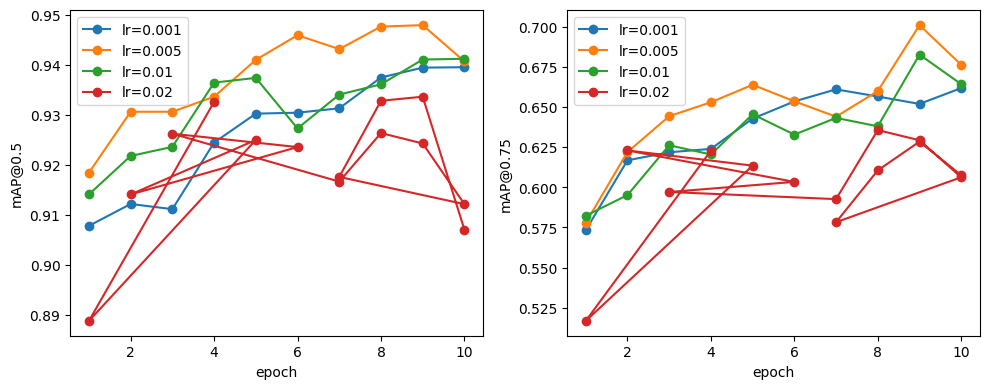

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name in LR_RUNS:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    tag = name.split("_lr")[1].replace("_hyper", "")
    lr = float("0." + tag[1:])
    ax[0].plot(df["epoch"], df["map50"], marker="o", label=f"lr={lr}")
    ax[1].plot(df["epoch"], df["map75"], marker="o", label=f"lr={lr}")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("mAP@0.5")
ax[0].legend()
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("mAP@0.75")
ax[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
WD_RUNS = [
    {"name": "wd0", "weight_decay": 0.0},
    {"name": "wd1e4", "weight_decay": 1e-4},
    {"name": "wd1e3", "weight_decay": 1e-3},
]

results = []
for spec in WD_RUNS:
    set_seed(42)
    model = build_fasterrcnn(trainable_backbone_layers=3)
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(
        params, lr=0.005, momentum=0.9, weight_decay=spec["weight_decay"],
    )
    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_l3_{spec['name']}_hyper")
    save_run_config(run_dir, {
        "lr": 0.005,
        "weight_decay": spec["weight_decay"],
        "epochs": 10,
        "schedule": "constant",
        "trainable_backbone_layers": 3,
        "optimizer": "SGD",
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })
    try:
        train_detection_run(
            model, optimizer, train_loader, val_loader, device, run_dir, epochs=10,
        )
        df = pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "weight_decay": spec["weight_decay"],
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"Failed: {spec['name']}: {e}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 239MB/s] 


Epoch 1, Step 200, Loss: 0.11334266209974884
Epoch 1, Step 400, Loss: 0.11431341486051678
AP@0.50  fire: 0.956
AP@0.50  smoke: 0.880
mAP@0.50: 0.918
AP@0.75  fire: 0.732
AP@0.75  smoke: 0.481
mAP@0.75: 0.607
Epoch 1: val_total 0.11293337747820316, map50 0.9181967764486942, map75 0.6065311286284442, 179.6542317867279s
Epoch 2, Step 200, Loss: 0.10765774054452777
Epoch 2, Step 400, Loss: 0.10532564913854003
AP@0.50  fire: 0.959
AP@0.50  smoke: 0.888
mAP@0.50: 0.924
AP@0.75  fire: 0.693
AP@0.75  smoke: 0.540
mAP@0.75: 0.616
Epoch 2: val_total 0.11187194911705936, map50 0.9235420035010378, map75 0.6164824505831062, 175.55367803573608s
Epoch 3, Step 200, Loss: 0.09450807021930814
Epoch 3, Step 400, Loss: 0.0965494797937572
AP@0.50  fire: 0.966
AP@0.50  smoke: 0.900
mAP@0.50: 0.933
AP@0.75  fire: 0.763
AP@0.75  smoke: 0.549
mAP@0.75: 0.656
Epoch 3: val_total 0.1074063456817273, map50 0.9332957246743228, map75 0.6556347601583319, 176.10318112373352s
Epoch 4, Step 200, Loss: 0.0893355052545666

In [ ]:
WD_NAMES = [
    ("fasterrcnn_v2_unfreeze_l3_wd0_hyper", 0.0),
    ("fasterrcnn_v2_unfreeze_l3_wd1e4_hyper", 1e-4),
    ("fasterrcnn_v2_unfreeze_l3_lr0005_hyper", 5e-4),
    ("fasterrcnn_v2_unfreeze_l3_wd1e3_hyper", 1e-3),
]
rows = []
for name, wd in WD_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["map50"].idxmax()]
    rows.append({
        "run": name,
        "weight_decay": wd,
        "best_epoch": int(best["epoch"]),
        "map50": float(best["map50"]),
        "map75": float(best["map75"]),
        "val_total": float(best["val_total"]),
    })
pd.DataFrame(rows)

,run,weight_decay,best_epoch,map50,map75,val_total
0,fasterrcnn_v2_unfreeze_l3_wd0_hyper,0.0000,5,0.946533,0.689818,0.103037
1,fasterrcnn_v2_unfreeze_l3_wd1e4_hyper,0.0001,8,0.951420,0.655366,0.102877
2,fasterrcnn_v2_unfreeze_l3_lr0005_hyper,0.0005,9,0.947919,0.700972,0.102411
3,fasterrcnn_v2_unfreeze_l3_wd1e3_hyper,0.0010,9,0.948297,0.689591,0.101154


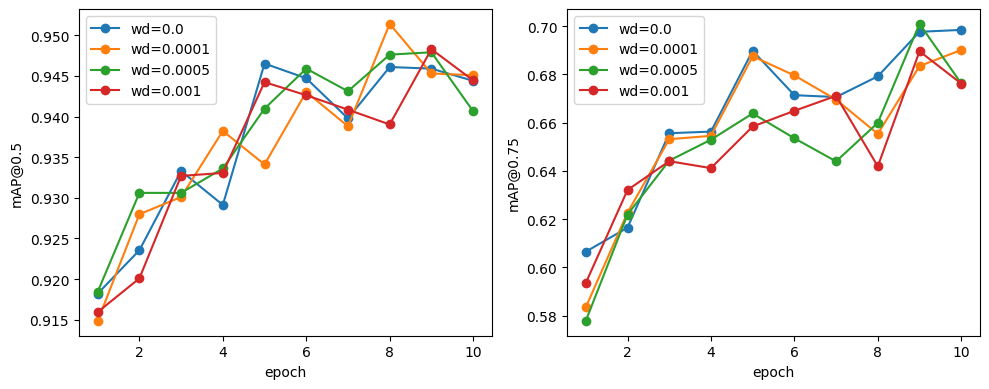

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name, wd in WD_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    label = f"wd={wd}"
    ax[0].plot(df["epoch"], df["map50"], marker="o", label=label)
    ax[1].plot(df["epoch"], df["map75"], marker="o", label=label)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("mAP@0.5")
ax[0].legend()
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("mAP@0.75")
ax[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
LAYER_RUNS = [
    {"name": "l1", "layers": 1},
    {"name": "l2", "layers": 2},
    {"name": "l4", "layers": 4},
    {"name": "l5", "layers": 5},
]

results = []
for spec in LAYER_RUNS:
    set_seed(42)
    model = build_fasterrcnn(trainable_backbone_layers=spec["layers"])
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_{spec['name']}_hyper")
    save_run_config(run_dir, {
        "lr": 0.005,
        "weight_decay": 0.0005,
        "epochs": 10,
        "trainable_backbone_layers": spec["layers"],
        "optimizer": "SGD",
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })

    try:
        train_detection_run(
            model, optimizer, train_loader, val_loader, device, run_dir, epochs=10,
        )
        df = pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "layers": spec["layers"],
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"failed {spec['name']}: {e}")

Epoch 1, Step 200, Loss: 0.11270435193553567
Epoch 1, Step 400, Loss: 0.1135930703766644
AP@0.50  fire: 0.945
AP@0.50  smoke: 0.844
mAP@0.50: 0.895
AP@0.75  fire: 0.683
AP@0.75  smoke: 0.408
mAP@0.75: 0.545
Epoch 1: val_total 0.1186570448149567, map50 0.894510319744239, map75 0.5454213015400647, 164.61624002456665s
Epoch 2, Step 200, Loss: 0.11047425173223019
Epoch 2, Step 400, Loss: 0.10929089583456517
AP@0.50  fire: 0.949
AP@0.50  smoke: 0.846
mAP@0.50: 0.898
AP@0.75  fire: 0.683
AP@0.75  smoke: 0.474
mAP@0.75: 0.578
Epoch 2: val_total 0.11932287481756298, map50 0.897808084591867, map75 0.5782210988802087, 164.667582988739s
Epoch 3, Step 200, Loss: 0.10206847794353963
Epoch 3, Step 400, Loss: 0.10367836136370898
AP@0.50  fire: 0.954
AP@0.50  smoke: 0.869
mAP@0.50: 0.912
AP@0.75  fire: 0.723
AP@0.75  smoke: 0.484
mAP@0.75: 0.604
Epoch 3: val_total 0.11836053168206859, map50 0.9116308282216059, map75 0.6035549874738324, 165.1021375656128s
Epoch 4, Step 200, Loss: 0.09812003757804633
Ep

In [ ]:
LAYER_NAMES = [
    ("fasterrcnn_v2_unfreeze_l1_hyper", 1),
    ("fasterrcnn_v2_unfreeze_l2_hyper", 2),
    ("fasterrcnn_v2_unfreeze_l3_lr0005_hyper", 3),
    ("fasterrcnn_v2_unfreeze_l4_hyper", 4),
    ("fasterrcnn_v2_unfreeze_l5_hyper", 5),
]

rows = []
for name, layers in LAYER_NAMES: 
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["map50"].idxmax()]
    rows.append({
        "run": name,
        "layers": layers,
        "best_epoch": int(best["epoch"]),
        "map50": float(best["map50"]),
        "map75": float(best["map75"]),
        "val_total": float(best["val_total"]),
    })

In [ ]:
pd.DataFrame(rows)

,run,layers,best_epoch,map50,map75,val_total
0,fasterrcnn_v2_unfreeze_l1_hyper,1,10,0.935434,0.642691,0.113192
1,fasterrcnn_v2_unfreeze_l2_hyper,2,9,0.942973,0.656577,0.108314
2,fasterrcnn_v2_unfreeze_l3_lr0005_hyper,3,9,0.947919,0.700972,0.102411
3,fasterrcnn_v2_unfreeze_l4_hyper,4,9,0.948366,0.685819,0.100443
4,fasterrcnn_v2_unfreeze_l5_hyper,5,8,0.952135,0.683765,0.101252


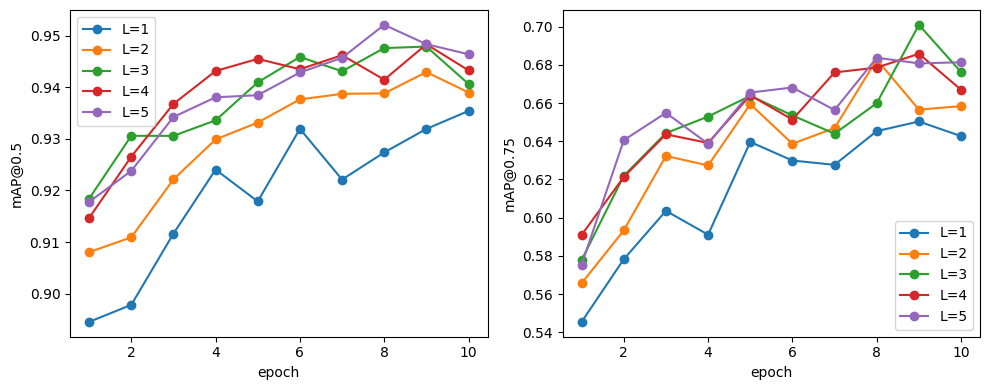

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name, layers in LAYER_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    ax[0].plot(df["epoch"], df["map50"], marker="o", label=f"L={layers}")
    ax[1].plot(df["epoch"], df["map75"], marker="o", label=f"L={layers}")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("mAP@0.5"); ax[0].legend()
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("mAP@0.75"); ax[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
OPTIMIZER_RUNS = ["sgd_nesterov", "adam", "adamw", "rmsprop"]

results = []
for name in OPTIMIZER_RUNS:
    set_seed(42)
    model= build_fasterrcnn(trainable_backbone_layers=3)
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)

    params = [p for p in model.parameters() if p.requires_grad]
    if name == "sgd_nesterov":
        optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, nesterov=True)
    elif name == "adamw":
        optimizer = torch.optim.AdamW(params, lr=0.005, weight_decay=0.0005)
    elif name == "rmsprop":
        optimizer = torch.optim.RMSprop(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_l3_{name}_hyper")
    save_run_config(run_dir, {"optimizer": name,
        "lr": 0.005,
        "weight_decay": 0.0005,
        "epochs": 10,
        "trainable_backbone_layers": 3,
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })

    try:
        train_detection_run(model, optimizer, train_loader, val_loader, device, run_dir, epochs=10)
        df=pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "optimizer": name,
            "lr": 0.005,
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"failed: {name}: {e}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 217MB/s]  


Epoch 1, Step 200, Loss: 0.11279817778617143
Epoch 1, Step 400, Loss: 0.11364413452334703
AP@0.50  fire: 0.957
AP@0.50  smoke: 0.877
mAP@0.50: 0.917
AP@0.75  fire: 0.711
AP@0.75  smoke: 0.451
mAP@0.75: 0.581
Epoch 1: val_total 0.11333746362500395, map50 0.9168242432933361, map75 0.5810698225815003, 178.01170802116394s
Epoch 2, Step 200, Loss: 0.10649791089817881
Epoch 2, Step 400, Loss: 0.10446376792155206
AP@0.50  fire: 0.961
AP@0.50  smoke: 0.888
mAP@0.50: 0.924
AP@0.75  fire: 0.701
AP@0.75  smoke: 0.538
mAP@0.75: 0.620
Epoch 2: val_total 0.11099445303342094, map50 0.9243111261109833, map75 0.619855258383011, 176.16194653511047s
Epoch 3, Step 200, Loss: 0.09432280033826829
Epoch 3, Step 400, Loss: 0.09570416932925582
AP@0.50  fire: 0.960
AP@0.50  smoke: 0.905
mAP@0.50: 0.933
AP@0.75  fire: 0.747
AP@0.75  smoke: 0.530
mAP@0.75: 0.638
Epoch 3: val_total 0.1059504791728558, map50 0.9326694936121968, map75 0.6382897438072642, 176.63538599014282s
Epoch 4, Step 200, Loss: 0.087954512964934

In [ ]:
pd.DataFrame(results)

,run,optimizer,lr,best_epoch,map50,map75,val_total
0,fasterrcnn_v2_unfreeze_l3_sgd_nesterov_hyper,sgd_nesterov,0.005,9,0.954160,0.688848,0.100375
1,fasterrcnn_v2_unfreeze_l3_adam_hyper,adam,0.005,3,0.891222,0.529421,0.121031
2,fasterrcnn_v2_unfreeze_l3_adamw_hyper,adamw,0.005,10,0.611902,0.130994,0.140698
3,fasterrcnn_v2_unfreeze_l3_rmsprop_hyper,rmsprop,0.005,1,0.000000,0.000000,4.335636


Adam, AdamW and RMSprop all used the same lr=0.005 that we picked for SGD. None of them trained properly. Adam stayed stuck near the freeze-head score. AdamW wrecked the weights in epoch 1 and only recovered to 0.61.RMSprop blew up.Adaptive optimizers usually need a much smaller lr, so this is not a fair test but in literature and documentations of torchvision, SGD based optimizers are best practise

In [ ]:
OPT_NAMES = [
    ("fasterrcnn_v2_unfreeze_l3_lr0005_hyper", "sgd_momentum"),
    ("fasterrcnn_v2_unfreeze_l3_sgd_nesterov_hyper", "sgd_nesterov"),
    ("fasterrcnn_v2_unfreeze_l3_adam_hyper", "adam"),
    ("fasterrcnn_v2_unfreeze_l3_adamw_hyper", "adamw"),
    ("fasterrcnn_v2_unfreeze_l3_rmsprop_hyper", "rmsprop"),
]
rows = []
for name, opt in OPT_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["map50"].idxmax()]
    rows.append({
        "run": name,
        "optimizer": opt,
        "best_epoch": int(best["epoch"]),
        "map50": float(best["map50"]),
        "map75": float(best["map75"]),
        "val_total": float(best["val_total"]),
    })
pd.DataFrame(rows)

,run,optimizer,best_epoch,map50,map75,val_total
0,fasterrcnn_v2_unfreeze_l3_lr0005_hyper,sgd_momentum,9,0.947919,0.700972,0.102411
1,fasterrcnn_v2_unfreeze_l3_sgd_nesterov_hyper,sgd_nesterov,9,0.954160,0.688848,0.100375
2,fasterrcnn_v2_unfreeze_l3_adam_hyper,adam,3,0.891222,0.529421,0.121031
3,fasterrcnn_v2_unfreeze_l3_adamw_hyper,adamw,10,0.611902,0.130994,0.140698
4,fasterrcnn_v2_unfreeze_l3_rmsprop_hyper,rmsprop,1,0.000000,0.000000,4.335636


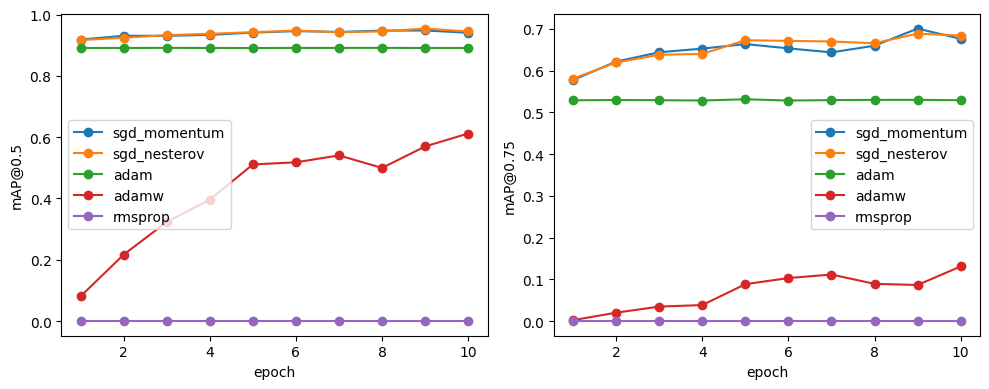

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name, opt in OPT_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    ax[0].plot(df["epoch"], df["map50"], marker="o", label=opt)
    ax[1].plot(df["epoch"], df["map75"], marker="o", label=opt)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("mAP@0.5"); ax[0].legend()
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("mAP@0.75"); ax[1].legend()
plt.tight_layout()
plt.show()

The RPN generates many possible object boxes but the box head trains on only a sample of them. box_batch_size_per_image controls how many proposals are selected while box_positive_fraction limits how many can represent real objects.

Since our images usually contain only a few fire or smoke objects we tested whether using fewer proposals or allowing more positives would help.

In [10]:
ROI_SAMPLE_RUNS = [
    # baseline posfrac025_bs512 = fasterrcnn_v2_unfreeze_l3_lr0005_hyper
    {"name": "posfrac025_bs256", "box_positive_fraction": 0.25, "box_batch_size_per_image": 256},
    {"name": "posfrac025_bs128", "box_positive_fraction": 0.25, "box_batch_size_per_image": 128},
    {"name": "posfrac050_bs128", "box_positive_fraction": 0.50, "box_batch_size_per_image": 128},
]

results = []
for spec in ROI_SAMPLE_RUNS:
    set_seed(42)
    model = build_fasterrcnn(
        trainable_backbone_layers=3,
        box_positive_fraction=spec["box_positive_fraction"],
        box_batch_size_per_image=spec["box_batch_size_per_image"],
    )
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_l3_{spec['name']}_hyper")
    save_run_config(run_dir, {
        "lr": 0.005,
        "weight_decay": 0.0005,
        "epochs": 10,
        "trainable_backbone_layers": 3,
        "box_positive_fraction": spec["box_positive_fraction"],
        "optimizer": "SGD",
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })
    try:
        train_detection_run(model, optimizer, train_loader, val_loader, device, run_dir, epochs=10)
        df = pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "box_positive_fraction": spec["box_positive_fraction"],
            "box_batch_size_per_image": spec["box_batch_size_per_image"],
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "ap50_fire": float(best["ap50_fire"]),
            "ap50_smoke": float(best["ap50_smoke"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"failed {spec['name']}: {e}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 209MB/s] 


Epoch 1, Step 200, Loss: 0.2004052770510316
Epoch 1, Step 400, Loss: 0.20273373628035188
AP@0.50  fire: 0.954
AP@0.50  smoke: 0.862
mAP@0.50: 0.908
AP@0.75  fire: 0.698
AP@0.75  smoke: 0.423
mAP@0.75: 0.561
Epoch 1: val_total 0.19562338946238617, map50 0.9079537403842968, map75 0.5607747740827036, 161.5940568447113s
Epoch 2, Step 200, Loss: 0.18457786466926338
Epoch 2, Step 400, Loss: 0.18035620115697384
AP@0.50  fire: 0.960
AP@0.50  smoke: 0.883
mAP@0.50: 0.922
AP@0.75  fire: 0.676
AP@0.75  smoke: 0.528
mAP@0.75: 0.602
Epoch 2: val_total 0.19171129025381767, map50 0.9218821206422465, map75 0.6021566793628923, 158.59558296203613s
Epoch 3, Step 200, Loss: 0.16379036597907543
Epoch 3, Step 400, Loss: 0.16648698516190052
AP@0.50  fire: 0.963
AP@0.50  smoke: 0.907
mAP@0.50: 0.935
AP@0.75  fire: 0.766
AP@0.75  smoke: 0.519
mAP@0.75: 0.643
Epoch 3: val_total 0.1778943080203665, map50 0.9348577749339213, map75 0.6429369980801105, 159.51731204986572s
Epoch 4, Step 200, Loss: 0.1543301798030734

In [11]:
pd.DataFrame(results)

,run,box_positive_fraction,box_batch_size_per_image,best_epoch,map50,map75,ap50_fire,ap50_smoke,val_total
0,fasterrcnn_v2_unfreeze_l3_posfrac025_bs256_hyper,0.25,256,10,0.948856,0.691536,0.969550,0.928161,0.174984
1,fasterrcnn_v2_unfreeze_l3_posfrac025_bs128_hyper,0.25,128,7,0.948392,0.631478,0.976939,0.919844,0.288460
2,fasterrcnn_v2_unfreeze_l3_posfrac050_bs128_hyper,0.50,128,8,0.942587,0.639541,0.960831,0.924343,0.303755


In [12]:
ROI_NAMES = [
    ("fasterrcnn_v2_unfreeze_l3_lr0005_hyper", 0.25, 512),
    ("fasterrcnn_v2_unfreeze_l3_posfrac025_bs256_hyper", 0.25, 256),
    ("fasterrcnn_v2_unfreeze_l3_posfrac025_bs128_hyper", 0.25, 128),
    ("fasterrcnn_v2_unfreeze_l3_posfrac050_bs128_hyper", 0.50, 128),
]

rows = []
for name, frac, bs in ROI_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["map50"].idxmax()]
    rows.append({
        "run": name,
        "box_positive_fraction": frac,
        "box_batch_size_per_image": bs,
        "best_epoch": int(best["epoch"]),
        "map50": float(best["map50"]),
        "map75": float(best["map75"]),
        "val_total": float(best["val_total"]),
    })
pd.DataFrame(rows)

,run,box_positive_fraction,box_batch_size_per_image,best_epoch,map50,map75,val_total
0,fasterrcnn_v2_unfreeze_l3_lr0005_hyper,0.25,512,9,0.947919,0.700972,0.102411
1,fasterrcnn_v2_unfreeze_l3_posfrac025_bs256_hyper,0.25,256,10,0.948856,0.691536,0.174984
2,fasterrcnn_v2_unfreeze_l3_posfrac025_bs128_hyper,0.25,128,7,0.948392,0.631478,0.288460
3,fasterrcnn_v2_unfreeze_l3_posfrac050_bs128_hyper,0.50,128,8,0.942587,0.639541,0.303755


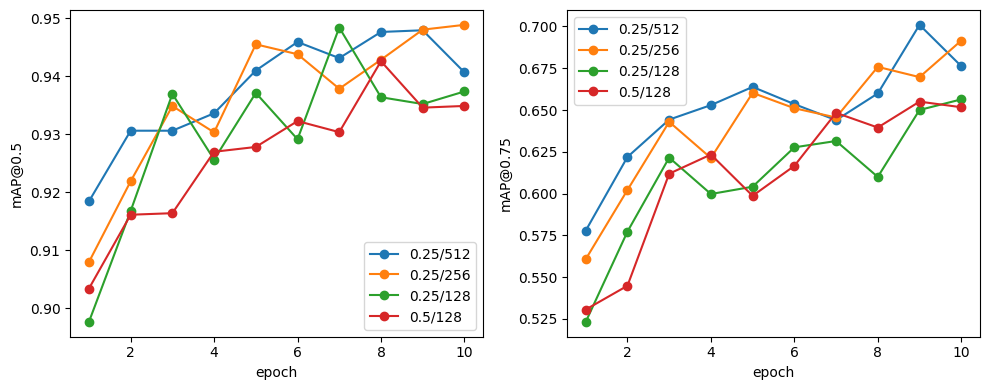

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name, frac, bs in ROI_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    label = f"{frac}/{bs}"
    ax[0].plot(df["epoch"], df["map50"], marker="o", label=label)
    ax[1].plot(df["epoch"], df["map75"], marker="o", label=label)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("mAP@0.5"); ax[0].legend()
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("mAP@0.75"); ax[1].legend()
plt.tight_layout()
plt.show()